<center>



### **Start of the Segmentation Project**




STEP 1: Creating the Dataset (but Dataset class will need RLE to binary conversion inside it. So lets prepare the rle_to_binaery def before moving to the Dataset class definition)

In [15]:
import numpy as np

def rle_to_binary(rle, shape):
    # 1. Handle the NaN/Empty case
    if pd.isna(rle): 
        return np.zeros(shape, dtype=np.uint8)

    # 2. Your existing logic
    if isinstance(rle, str):
        rle = [int(x) for x in rle.split()]

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    for i in range(0, len(rle), 2):
        start = rle[i] - 1
        length = rle[i+1]
        mask[start : start + length] = 1
        
    return mask.reshape(shape, order='C')


Ok now we are good to proceed with Dataset definition:

In [16]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path



class MadisonDataset(Dataset):
    def __init__(self, csv_file, img_dir, target_size=(256, 256), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = Path (img_dir)
        self.target_size = target_size 
        self.ids = self.df['id'].unique()
        self.grouped = self.df.groupby('id')
        self.classes = ['large_bowel', 'small_bowel', 'stomach']
        self.transform = transform


        #path mapping##
        self.path_map = {}
        for file_path in self.img_dir.rglob("*.png"):
            # 1. Get the 'day' folder name (e.g., 'case123_day0')
            day_folder = file_path.parent.parent.name 
            
            # 2. Get the 'slice' part (e.g., 'slice_0001')
            slice_part = file_path.stem.split('_')[0] + "_" + file_path.stem.split('_')[1]
            
            # 3. Construct the ID to match your CSV format: 'case123_day0_slice_0001'
            constructed_id = f"{day_folder}_{slice_part}"
            
            # Add to dictionary
            self.path_map[constructed_id] = str(file_path)


    def __len__(self):
        return len(self.ids) #self.id is defined above in __init__

    def __getitem__(self, idx):
        sample_id = self.ids[idx]
         
        # --- Look up the path in our pre-built dictionary ---
        img_path = self.path_map.get(sample_id)
        if img_path is None:
            raise FileNotFoundError(f"Could not find image for {sample_id}")
        
        

        ##### Next line of code is soley for sanity checking, comment out while on real evaluation
        #print(f"DEBUG: Index {idx} | ID: {sample_id} | File: {Path(img_path).name}") # used only for sanity checking
        ###########################
           
        
        
        
        img = Image.open(img_path).convert('I') # ('I') ensures that 16bit image data are preserved
        # PIL.Image.size returns (width, height), so we swap for our function
        w, h = img.size 
        native_shape = (h, w)
        
        # 2. Resize image for the model
        img_resized = img.resize(self.target_size, resample=Image.BILINEAR)
        image_arr = np.array(img_resized, dtype=np.float32) / 603
        
        # 3. Decode masks using the native shape
        masks = []
        rows = self.grouped.get_group(sample_id)
        
        for cls in self.classes:
            row = rows[rows['class'] == cls]
            rle = row.iloc[0]['segmentation'] if len(row) > 0 else np.nan
            
            # Use our helper function with the dynamic native_shape
            mask = rle_to_binary(rle, native_shape)
            
            # Resize mask (Use NEAREST to preserve binary 0/1)
            mask_pil = Image.fromarray(mask)
            mask_resized = mask_pil.resize(self.target_size, resample=Image.NEAREST)
            masks.append(np.array(mask_resized))

        
        # 4. Stack masks
        mask_stack = np.stack(masks, axis=0)  # (3,256,256)

        # Convert to H,W,C for albumentations
        mask_stack = np.transpose(mask_stack, (1,2,0))  # (256,256,3)

        # --- Apply augmentation ---
        if self.transform is not None:
            augmented = self.transform(image=image_arr, mask=mask_stack)
            image_arr = augmented["image"]
            mask_stack = augmented["mask"]

        # Ensure masks remain binary
        mask_stack = (mask_stack > 0.5).astype(np.float32)

        # Convert back to C,H,W
        mask_stack = np.transpose(mask_stack, (2,0,1))  # (3,256,256)

        # Convert image to C,H,W
        image_arr = np.expand_dims(image_arr, axis=0)   # (1,256,256)

        return (
            torch.from_numpy(image_arr).float(),
            torch.from_numpy(mask_stack).float()
            )



In [17]:
#Adding augmentation feature

import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.5
    ),
])

val_transform = None



/Users/ali/Library/Python/3.9/lib/python/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


STEP 2: Splitting

In [18]:
from sklearn.model_selection import train_test_split

full_df = pd.read_csv("/Users/ali/Desktop/madison/train.csv")
full_df['case_id'] = full_df['id'].str.split('_').str[0]

all_case_ids = full_df['case_id'].unique()
train_ids, val_ids = train_test_split(all_case_ids, test_size=0.2, random_state=42)

train_df = full_df[full_df['case_id'].isin(train_ids)].copy()
val_df   = full_df[full_df['case_id'].isin(val_ids)].copy()






####### Mini-Dataset (comment out this block for full training) ########
#def sample_by_slice(df, n_slices, seed=42):
#    ids = df['id'].drop_duplicates().sample(frac=1, random_state=seed).head(n_slices)
#    return df[df['id'].isin(ids)].copy()

#train_df = sample_by_slice(train_df, n_slices=100)
#val_df   = sample_by_slice(val_df, n_slices=20)
######################################################################





train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)


In [19]:
# Instanciate dataset class
train_dataset = MadisonDataset(csv_file='/Users/ali/Desktop/train_split.csv' , img_dir= '/Users/ali/Desktop/madison/train', transform=train_transform)
val_dataset = MadisonDataset(csv_file= '/Users/ali/Desktop/val_split.csv', img_dir= '/Users/ali/Desktop/madison/train', transform=None)

STEP 3: DataLoader definition

In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

STEP 4: Model

In [21]:
import segmentation_models_pytorch as smp

model_segmentator = smp.Unet(
    encoder_name= 'timm-efficientnet-b4', 
    encoder_weights='imagenet',
    in_channels=1,       # MUST be 1 because your images are grayscale
    classes=3,           # This is correct (Stomach, Small Bowel, Large Bowel)
    activation=None      # MUST be None to output raw logits for BCEWithLogitsLoss
)


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model_segmentator = model_segmentator.to(device)

In [22]:
#now load the classifier model

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

class ClassifierModel(nn.Module):

    def __init__(self, encoder_name="resnet34", encoder_weights=None):
        super().__init__()

        self.encoder = smp.encoders.get_encoder(
            encoder_name,
            in_channels=1,
            weights=encoder_weights
        )

        encoder_channels = self.encoder.out_channels[-1]

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(encoder_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.encoder(x)
        x = features[-1]
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [23]:
classifier = ClassifierModel(
    encoder_name="resnet34",
    encoder_weights=None
)

state_dict = torch.load(
    "/Users/ali/Desktop/Saved/best_classifier_recall.pth",
    map_location=device
)

classifier.load_state_dict(state_dict)

classifier = classifier.to(device)
classifier.eval()

CLS_THRESHOLD = 0.1


STEP 5: Choose the LossFunction and Optimizer

In [24]:
dice_loss = smp.losses.DiceLoss(mode='multilabel')
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def dice_bce_loss_function (predicted_logits, targets):
    return bce_loss(predicted_logits, targets) + dice_loss(predicted_logits, targets)

In [25]:
optimizer = torch.optim.Adam(model_segmentator.parameters(), lr=1e-3)

In [26]:
# Instanciate dataset class
train_dataset = MadisonDataset(csv_file='/Users/ali/Desktop/train_split.csv' , img_dir= '/Users/ali/Desktop/madison/train', transform=train_transform)
val_dataset = MadisonDataset(csv_file= '/Users/ali/Desktop/val_split.csv', img_dir= '/Users/ali/Desktop/madison/train', transform=None)

STEP 6: Trainig and Validation

In [27]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch

def train(train_loader, model, dice_bce_loss_function, optimizer, train_dataset, device):
    model.train()
    loss_sum = 0.0
    total_samples = 0

    for x_batch, y_batch in tqdm(train_loader):
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()

        # Train segmentator only on slices that actually contain mask pixels
        has_mask = y_batch.sum(dim=(1, 2, 3)) > 0

        if has_mask.sum() == 0:
            continue

        x_batch = x_batch[has_mask]
        y_batch = y_batch[has_mask]

        optimizer.zero_grad()

        y_predicted = model(x_batch)
        loss = dice_bce_loss_function(y_predicted, y_batch)

        loss.backward()
        optimizer.step()

        batch_size = x_batch.size(0)
        loss_sum += loss.item() * batch_size
        total_samples += batch_size

    return loss_sum / total_samples if total_samples > 0 else 0.0




def calculate_dice(y_logits, y_true, smooth=1e-6):

    y_pred = (torch.sigmoid(y_logits) > 0.5).float()

    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)

    intersection = (y_pred * y_true).sum()

    return (2. * intersection + smooth) / (
        y_pred.sum() + y_true.sum() + smooth
    )


def validation(val_loader, model, classifier, CLS_THRESHOLD, val_dataset, dice_bce_loss_function, device):
    model.eval()
    classifier.eval()

    loss_sum = 0.0
    dice_sum = 0.0
    total_samples = 0

    with torch.no_grad():
        for x_batch_val, y_batch_val in val_loader:
            x_batch_val = x_batch_val.to(device).float()
            y_batch_val = y_batch_val.to(device).float()

            cls_logits = classifier(x_batch_val)
            cls_probs = torch.sigmoid(cls_logits).view(-1)

            positive_idx = cls_probs > CLS_THRESHOLD

            y_predicted_val = torch.zeros_like(y_batch_val)

            if positive_idx.sum() > 0:
                y_predicted_val[positive_idx] = model(x_batch_val[positive_idx])

            loss_val = dice_bce_loss_function(y_predicted_val, y_batch_val)
            dice_val = calculate_dice(y_predicted_val, y_batch_val)

            batch_size = x_batch_val.size(0)
            loss_sum += loss_val.item() * batch_size
            dice_sum += dice_val.item() * batch_size
            total_samples += batch_size

    return loss_sum / total_samples, dice_sum / total_samples




def learning_curve_plotter(list1, list2):

    plt.plot(list1, label='train_set')
    plt.plot(list2, label='val_set')

    plt.xlabel('epoch')
    plt.ylabel('loss')

    plt.legend()

    plt.show()


def operator(train_loader, val_loader, model, classifier, CLS_THRESHOLD,
             loss_fn, optimizer, train_dataset, val_dataset, n_epoch, device):

    list1 = []
    list2 = []

    best_dice_val = -torch.inf
    best_loss_val = torch.inf

    for epoch in range(n_epoch):

        mean_loss_train = train(
            train_loader,
            model_segmentator,
            loss_fn,
            optimizer,
            train_dataset,
            device
        )

        mean_loss_val, mean_dice_val = validation(
            val_loader,
            model_segmentator,
            classifier,
            CLS_THRESHOLD,
            val_dataset,
            loss_fn,
            device
        )

        list1.append(mean_loss_train)
        list2.append(mean_loss_val)

        print(f'Epoch {epoch+1}/{n_epoch} --> '
              f'train_loss: {mean_loss_train:.4f}, '
              f'val_loss: {mean_loss_val:.4f}, '
              f'val_dice: {mean_dice_val:.4f}')

        if mean_dice_val > best_dice_val:
            torch.save(
                model_segmentator,
                '/Users/ali/Desktop/Saved/best_model_dice_oriented.pth'
            )
            best_dice_val = mean_dice_val
            print('model saved! Dice-Oriented')

        if mean_loss_val < best_loss_val:
            torch.save(
                model_segmentator,
                '/Users/ali/Desktop/Saved/best_model_loss_oriented.pth'
            )
            best_loss_val = mean_loss_val
            print('model saved! Loss-Oriented')

    learning_curve_plotter(list1, list2)


100%|██████████| 1913/1913 [21:18<00:00,  1.50it/s]


Epoch 1/30 --> train_loss: 0.3988, val_loss: 0.5742, val_dice: 0.7849
model saved! Dice-Oriented
model saved! Loss-Oriented


100%|██████████| 1913/1913 [24:08<00:00,  1.32it/s]


Epoch 2/30 --> train_loss: 0.2445, val_loss: 0.5726, val_dice: 0.7664
model saved! Loss-Oriented


100%|██████████| 1913/1913 [24:35<00:00,  1.30it/s]


...

Epoch 28/30 --> train_loss: 0.1350, val_loss: 0.5414, val_dice: 0.8154


100%|██████████| 1913/1913 [21:36<00:00,  1.48it/s]


Epoch 29/30 --> train_loss: 0.1301, val_loss: 0.5405, val_dice: 0.8311


100%|██████████| 1913/1913 [21:30<00:00,  1.48it/s]


Epoch 30/30 --> train_loss: 0.1296, val_loss: 0.5448, val_dice: 0.8230


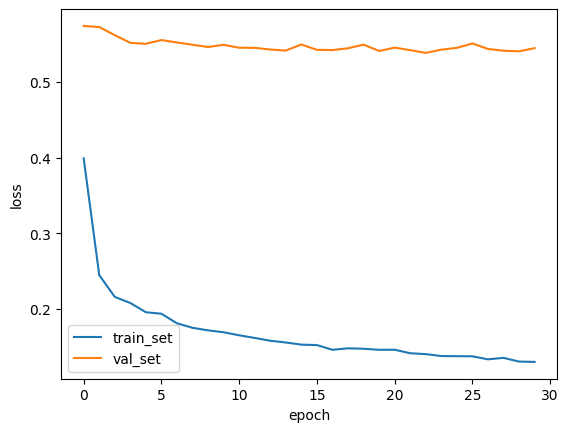

In [28]:
CLS_THRESHOLD = 0.1 # Or whatever threshold you determined

operator(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model_segmentator.to(device),
    classifier=classifier,        # <-- ADD THIS
    CLS_THRESHOLD=CLS_THRESHOLD,   # <-- ADD THIS
    loss_fn=dice_bce_loss_function,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    n_epoch=30
)
